# CIFAR-10 Image Classification with Transfer Learning (ResNet50)

## Project goal
We build an end-to-end image classification pipeline for **CIFAR-10** (10 classes, 32×32 RGB images) using **transfer learning** with a pretrained **ResNet50** model.

**What matters for this project**
- A correct, reproducible workflow (data → preprocessing → model → training → evaluation).
- Clear reasoning and documented decisions (why we do each step).
- Observations during training (stability, overfitting, trends), not only the final accuracy.

**Compute note**
Training a CNN (especially fine-tuning) can take a long time on CPU. In Colab, switching runtime to GPU can reduce training time significantly.


## 0. Plan & deliverables

**Deliverables in this notebook**
1. Dataset loading + sampling logic (`n=10000` train)
2. EDA and sanity checks (shapes, labels, class balance, example images)
3. Preprocessing pipeline compatible with ResNet50
4. Model architecture (ResNet50 base + custom head)
5. Two-stage training (freeze → train head, then unfreeze → fine-tune)
6. Evaluation on the test set + interpretation
7. A short conclusion section to translate into Google Slides

**Observations log (we will update as we go)**
- Decisions made and why
- Training behavior (learning curves)
- Limitations (runtime, hardware)
- What we would improve next


## 1. Setup: imports, reproducibility, and hardware

**Why this section exists**
- Imports: everything needed in one place.
- Reproducibility: seeding reduces randomness (not perfect with GPU, but still useful).
- Hardware check: training speed depends heavily on GPU availability.


### Colab runtime checklist (GPU + TensorFlow)

**Goal**: make sure we run on GPU and TensorFlow is installed before importing it.

1. `Runtime` → `Change runtime type` → `Hardware accelerator` → **GPU**
2. If TensorFlow import fails, the next cell will install it automatically.

After running the next cell, you should see:
- TensorFlow version printed
- `Num GPUs Available` is `> 0` (if GPU is enabled)


### What we install/import (and why)

- **NumPy**: numerical arrays; used for label counts and basic manipulation.
- **Matplotlib**: visualization of sample images and training curves.
- **TensorFlow / Keras**: deep learning framework; provides CIFAR-10 loader, ResNet50, training API.

We install TensorFlow only if it is missing in the current runtime.


### TensorFlow installation (local Jupyter)

If you are running this notebook **locally in Jupyter** (not Google Colab), TensorFlow must be installed into the **same Python environment / kernel** that Jupyter uses.

**Why installation sometimes 'does not work'**
- You installed TensorFlow into a different Python (e.g., system Python), while Jupyter runs from a virtualenv/conda env.
- No internet access / blocked network.
- Platform-specific build issues (macOS Intel vs Apple Silicon).

**Step 1: confirm which Python your notebook uses** (run the next cell).
**Step 2: install TensorFlow using that exact Python**.


In [65]:
import sys
print('Python executable used by THIS notebook:')
print(sys.executable)

# After you see the path above, install TensorFlow in a terminal using the SAME python:
#   <that_python> -m pip install -U pip
#   <that_python> -m pip install tensorflow
# Example:
#   /path/to/python -m pip install tensorflow


Python executable used by THIS notebook:
/Users/egortatsiy/Projects/CV project/.venv/bin/python


In [66]:
# Standard library
import os          # OS utilities (paths, environment variables).
import random      # Randomness control for reproducibility (Python-level RNG).

# Numeric computing
import numpy as np # Arrays + fast numeric ops; used for label distribution and basic data handling.

# Visualization
import matplotlib.pyplot as plt  # Plot sample images and training curves.

# Deep Learning framework
import tensorflow as tf  # TensorFlow provides Keras API, pretrained ResNet50, training loops, GPU support.

# Local (no-network) CIFAR-10 loader
import sys
sys.path.insert(0, 'scripts')
from local_cifar10 import load_cifar10_from_tar

# Keras utilities we will use
from tensorflow.keras import layers, models                        # Layers + Model API.
from tensorflow.keras.applications import ResNet50                 # Pretrained backbone.
from tensorflow.keras.applications.resnet50 import preprocess_input # Correct preprocessing for ResNet50 ImageNet weights.

# Make Matplotlib cache writable in this repo (avoids slow / permission warnings)
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('artifacts/mplconfig'))

print('TensorFlow:', tf.__version__)
print('Num GPUs Available:', len(tf.config.list_physical_devices('GPU')))

# CIFAR-10 class names (used across the notebook)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
assert len(class_names) == 10


TensorFlow: 2.20.0
Num GPUs Available: 0


## Plot style (for presentation)

A consistent look for all figures so screenshots are slide-ready and professional.


In [67]:
import matplotlib as mpl

def set_plot_style():
    mpl.rcParams.update({
        'figure.dpi': 120,
        'savefig.dpi': 160,
        'axes.grid': True,
        'grid.alpha': 0.25,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.titleweight': 'bold',
        'axes.labelsize': 11,
        'axes.titlesize': 13,
        'legend.frameon': False,
        'font.size': 11,
    })

set_plot_style()


## 2. Load CIFAR-10 and limit training set to 10k

**Why we limit the train set**
- CIFAR-10 has 50k training images. For this sprint, we use **10,000** to keep training time manageable.
- We limit *once* at the start to keep the rest of the notebook consistent.

**Note about splits**
We will create our own **train/validation/test** split from this 10k subset (stratified). We do **not** use the official CIFAR-10 test set in this notebook to avoid mixing evaluation protocols.

**What we expect (before splitting)**
- `train_images_full`: `(10000, 32, 32, 3)`
- `train_labels_full`: `(10000, 1)`


In [68]:
data = load_cifar10_from_tar('.keras/datasets/cifar-10-python.tar.gz')
(train_images_full, train_labels_full), _ = (data.x_train, data.y_train), (data.x_test, data.y_test)

n = globals().get('N_SAMPLES', 10_000)
train_images_full = train_images_full[:n]
train_labels_full = train_labels_full[:n]

print('train_images_full:', train_images_full.shape, train_images_full.dtype)
print('train_labels_full:', train_labels_full.shape, train_labels_full.dtype)


train_images_full: (20000, 32, 32, 3) uint8
train_labels_full: (20000, 1) int64


## Class names

We define class names early because multiple plots (including the split/stratification check) rely on them.


In [69]:
if 'class_names' not in globals():
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
assert len(class_names) == 10


## 2.5. Stratified split: train / validation / test

We take the **10,000**-image subset and split it into:
- **90% train**
- **3% validation**
- **7% test**

We **stratify by label** so each split keeps (approximately) the same class proportions.


## Experiment configuration

Set the experiment id/name and data split here. The notebook will log results to `artifacts/experiments.jsonl`.

Recommended for stable validation: **80/10/10**.


In [ ]:
EXP_ID = 'exp08'
EXP_NAME = '50k_80-10-10_aug_cifar_resnet20_scratch'
DATASET_NAME = 'CIFAR-10 (train subset)'
N_SAMPLES = 50_000

# Split ratios (must sum to 1.0)
SPLIT_TRAIN = 0.80
SPLIT_VAL = 0.10
SPLIT_TEST = 0.10

RANDOM_STATE = 42

# Model choice
# - 'resnet50_tl': transfer learning with cached ResNet50 ImageNet weights (fast to iterate)
# - 'cifar_resnet20': train a small ResNet from scratch on CIFAR-10 (no external weights)
MODEL_TYPE = 'cifar_resnet20'

# Experiment toggles
USE_AUGMENTATION = True
RUN_BASELINES = False
RUN_CATBOOST = False  # CatBoost can be slow; keep off for LogReg-only baseline


In [71]:
from sklearn.model_selection import train_test_split

# We split ONLY the 10k subset (no leakage from the official CIFAR-10 test set)
X = train_images_full
y = train_labels_full

y_flat = y.reshape(-1)

# 1) Hold out 7% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=SPLIT_TEST,
    random_state=RANDOM_STATE,
    stratify=y_flat
)

# 2) From the remaining 93%, take 3% validation (=> 3/93 of trainval)
val_frac_of_trainval = SPLIT_VAL / (1.0 - SPLIT_TEST)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_frac_of_trainval,
    random_state=RANDOM_STATE,
    stratify=y_trainval.reshape(-1)
)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val  :', X_val.shape, 'y_val  :', y_val.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)

# Sanity-check class balance
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    unique, counts = np.unique(yy.reshape(-1), return_counts=True)
    dist = dict(zip(unique.tolist(), counts.tolist()))
    print(name, dist)


X_train: (15999, 32, 32, 3) y_train: (15999, 1)
X_val  : (2001, 32, 32, 3) y_val  : (2001, 1)
X_test : (2000, 32, 32, 3) y_test : (2000, 1)
train {0: 1591, 1: 1585, 2: 1634, 3: 1609, 4: 1607, 5: 1540, 6: 1630, 7: 1621, 8: 1610, 9: 1572}
val {0: 199, 1: 198, 2: 204, 3: 201, 4: 201, 5: 193, 6: 204, 7: 203, 8: 201, 9: 197}
test {0: 199, 1: 198, 2: 204, 3: 201, 4: 201, 5: 192, 6: 204, 7: 203, 8: 201, 9: 197}


### Stratification check: class distribution by split

The plot shows that class proportions in train/val/test are (almost) identical.


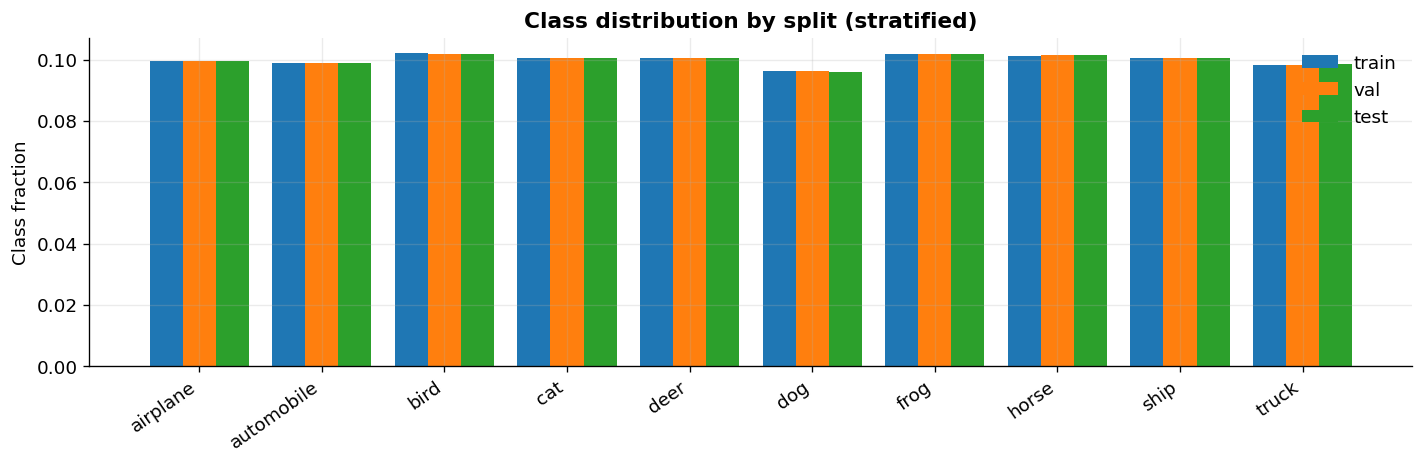

In [72]:
# Make this cell runnable even if executed out of order
if 'class_names' not in globals():
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def class_counts(y):
    y = y.reshape(-1)
    unique, counts = np.unique(y, return_counts=True)
    out = np.zeros(len(class_names), dtype=int)
    for u, c in zip(unique, counts):
        out[int(u)] = int(c)
    return out

cnt_train = class_counts(y_train)
cnt_val = class_counts(y_val)
cnt_test = class_counts(y_test)

frac_train = cnt_train / cnt_train.sum()
frac_val = cnt_val / cnt_val.sum()
frac_test = cnt_test / cnt_test.sum()

x = np.arange(len(class_names))
width = 0.27

plt.figure(figsize=(12, 4))
plt.bar(x - width, frac_train, width, label='train')
plt.bar(x,         frac_val,   width, label='val')
plt.bar(x + width, frac_test,  width, label='test')
plt.xticks(x, class_names, rotation=35, ha='right')
plt.ylabel('Class fraction')
plt.title('Class distribution by split (stratified)')
plt.legend()
plt.tight_layout()
plt.show()


✍️ **Fill after run (for report/slides)**

- Split sizes (train/val/test): **[paste here]**
- Stratification check: class fractions look **[similar / different]** across splits.
- Note: validation is only 3% (~300 images) → metrics may be noisy.


## 3. EDA: labels, class names, and sample images

**Why EDA matters (even for deep learning)**
- Ensures labels are in the expected format.
- Checks class distribution (sampling bugs happen).
- Confirms images look reasonable (RGB, no corruption).

We will:
- define class names,
- check label distribution,
- visualize a small grid of images.


In [73]:
train_labels_flat = y_train.flatten()

unique, counts = np.unique(train_labels_flat, return_counts=True)
for u, c in zip(unique, counts):
    print(f'{u}: {class_names[u]:>10} -> {c}')


0:   airplane -> 1591
1: automobile -> 1585
2:       bird -> 1634
3:        cat -> 1609
4:       deer -> 1607
5:        dog -> 1540
6:       frog -> 1630
7:      horse -> 1621
8:       ship -> 1610
9:      truck -> 1572


In [74]:
def show_image_grid(images, labels, class_names, n_rows=3, n_cols=6, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(images), size=n_rows*n_cols, replace=False)

    plt.figure(figsize=(2.2*n_cols, 2.2*n_rows))
    for i, j in enumerate(idx, start=1):
        plt.subplot(n_rows, n_cols, i)
        plt.imshow(images[j])
        plt.title(class_names[int(labels[j])])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


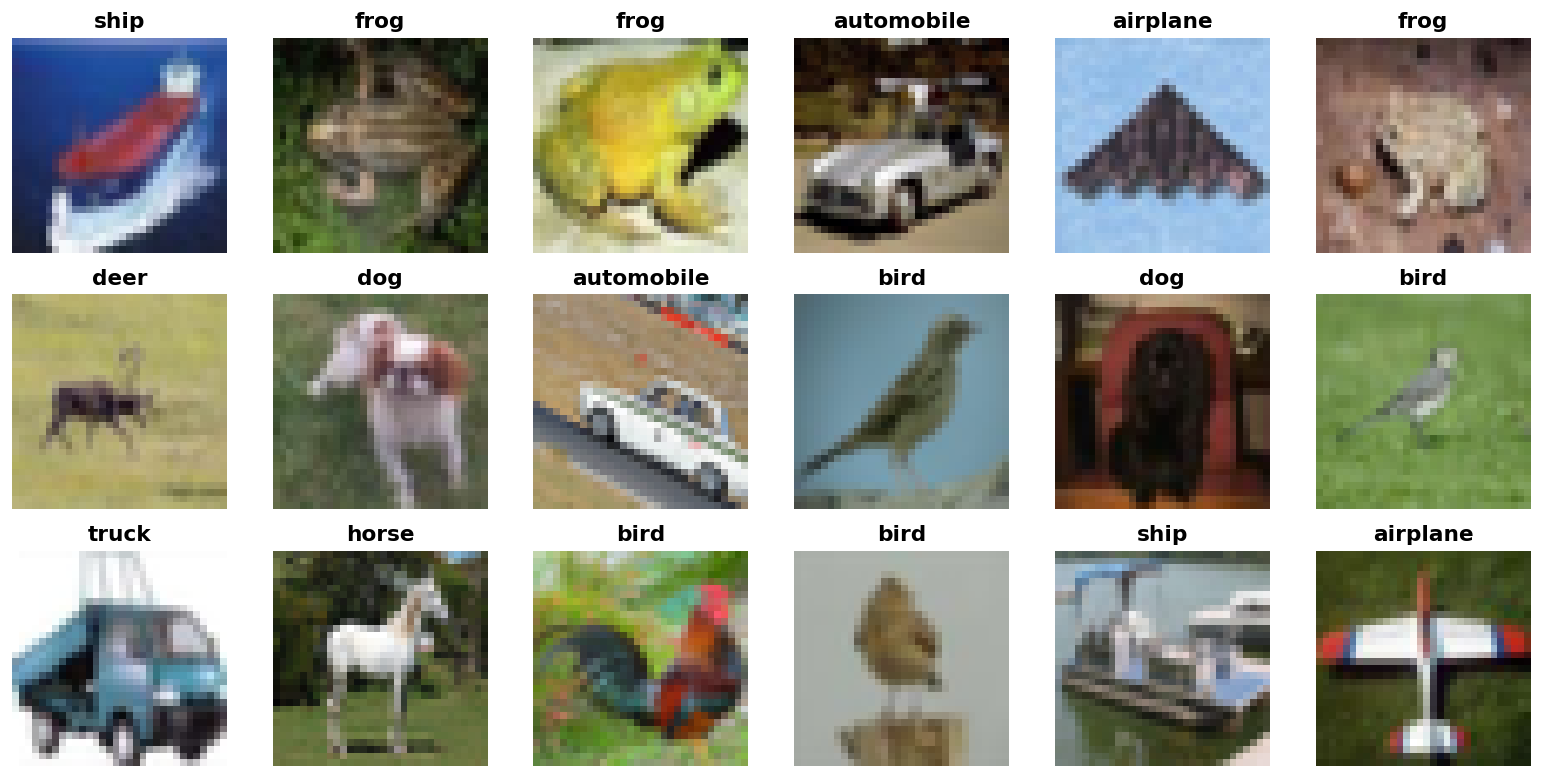

In [75]:
show_image_grid(X_train, y_train.flatten(), class_names)


## 4. Preprocessing

**Key decision**: preprocessing depends on `MODEL_TYPE`.

**Why**
- For `resnet50_tl`: use the matching `tf.keras.applications.resnet50.preprocess_input`.
- For `cifar_resnet20`: scale to `[0, 1]` (train from scratch).

We will keep two versions:
- raw images for visualization (`uint8`),
- preprocessed images for the model (`float32`).


In [76]:
X_train_raw = X_train
X_val_raw = X_val
X_test_raw = X_test

if MODEL_TYPE == 'resnet50_tl':
    X_train_pp = preprocess_input(X_train_raw.astype('float32'))
    X_val_pp = preprocess_input(X_val_raw.astype('float32'))
    X_test_pp = preprocess_input(X_test_raw.astype('float32'))
else:
    X_train_pp = (X_train_raw.astype('float32') / 255.0)
    X_val_pp = (X_val_raw.astype('float32') / 255.0)
    X_test_pp = (X_test_raw.astype('float32') / 255.0)

print('X_train_pp:', X_train_pp.shape, X_train_pp.dtype)
print('pp value range (train):', float(X_train_pp.min()), 'to', float(X_train_pp.max()))


X_train_pp: (15999, 32, 32, 3) float32
pp value range (train): -123.68000030517578 to 151.06100463867188


## Training input pipeline (optional augmentation)

If `USE_AUGMENTATION=True`, we train using an on-the-fly augmented `tf.data` pipeline.
Validation and test are **not** augmented.


In [77]:
AUTOTUNE = tf.data.AUTOTUNE

def augment_image(x):
    # x is uint8 [0..255]
    x = tf.cast(x, tf.float32)
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, max_delta=0.1)
    x = tf.image.random_contrast(x, lower=0.8, upper=1.2)
    x = tf.image.resize_with_crop_or_pad(x, 36, 36)
    x = tf.image.random_crop(x, size=[32, 32, 3])
    return x

def preprocess_batch(x, y):
    x = tf.cast(x, tf.float32)
    if MODEL_TYPE == 'resnet50_tl':
        x = preprocess_input(x)
    else:
        x = x / 255.0
    return x, y

train_ds = tf.data.Dataset.from_tensor_slices((X_train_raw, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val_raw, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test_raw, y_test))

if USE_AUGMENTATION:
    train_ds = train_ds.shuffle(10_000, seed=RANDOM_STATE, reshuffle_each_iteration=True)
    train_ds = train_ds.map(lambda x, y: (augment_image(x), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.map(preprocess_batch, num_parallel_calls=AUTOTUNE).batch(64).prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess_batch, num_parallel_calls=AUTOTUNE).batch(64).prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess_batch, num_parallel_calls=AUTOTUNE).batch(64).prefetch(AUTOTUNE)

print('Augmentation enabled:', USE_AUGMENTATION)


Augmentation enabled: False


## 5. Model: ResNet50 base + custom head

**Transfer learning structure**
- **Base model**: ResNet50 pretrained on ImageNet (`weights='imagenet'`).
- **Head**: trainable classifier for 10 CIFAR-10 classes.

**Why freeze first**
Freezing the base:
- makes training faster,
- reduces the risk of destroying pretrained features early,
- lets the head adapt to the new task first.


In [78]:
def build_cifar_resnet20(input_shape=(32, 32, 3), num_classes=10, wd=1e-4):
    def conv_bn_relu(x, filters, kernel_size=3, strides=1):
        x = layers.Conv2D(filters, kernel_size, strides=strides, padding='same', use_bias=False,
                          kernel_regularizer=tf.keras.regularizers.l2(wd))(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        return x

    def residual_block(x, filters, downsample=False):
        strides = 2 if downsample else 1
        shortcut = x
        y = layers.Conv2D(filters, 3, strides=strides, padding='same', use_bias=False,
                          kernel_regularizer=tf.keras.regularizers.l2(wd))(x)
        y = layers.BatchNormalization()(y)
        y = layers.ReLU()(y)
        y = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False,
                          kernel_regularizer=tf.keras.regularizers.l2(wd))(y)
        y = layers.BatchNormalization()(y)

        if downsample or shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, 1, strides=strides, padding='same', use_bias=False,
                                     kernel_regularizer=tf.keras.regularizers.l2(wd))(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)

        out = layers.Add()([shortcut, y])
        out = layers.ReLU()(out)
        return out

    inputs = layers.Input(shape=input_shape)
    x = conv_bn_relu(inputs, 16, 3, 1)
    for _ in range(3):
        x = residual_block(x, 16, downsample=False)
    x = residual_block(x, 32, downsample=True)
    for _ in range(2):
        x = residual_block(x, 32, downsample=False)
    x = residual_block(x, 64, downsample=True)
    for _ in range(2):
        x = residual_block(x, 64, downsample=False)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

if MODEL_TYPE == 'resnet50_tl':
    base_model = ResNet50(
        weights='.keras/models/resnet50_notop.h5',
        include_top=False,
        input_shape=(32, 32, 3)
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(32, 32, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = models.Model(inputs, outputs)
else:
    base_model = None
    model = build_cifar_resnet20()

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 6. Compile

**Loss & labels**
CIFAR-10 labels are integers, so we use `SparseCategoricalCrossentropy`.

**Metrics**
We track accuracy to measure classification performance.

We start with Adam and a moderate learning rate for head training.


In [79]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)


## 7. Stage 1 training: train the head (base frozen)

**Goal**
Learn a classifier head on top of fixed pretrained features.

**Runtime note**
This should be faster than fine-tuning.


In [80]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
]

if USE_AUGMENTATION:
    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=callbacks,
        verbose=1
    )
else:
    history_head = model.fit(
        X_train_pp, y_train,
        validation_data=(X_val_pp, y_val),
        epochs=10,
        batch_size=64,
        callbacks=callbacks,
        verbose=1
    )


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.4504 - loss: 2.1181 - val_accuracy: 0.5982 - val_loss: 1.1411
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.6289 - loss: 1.0614 - val_accuracy: 0.6187 - val_loss: 1.1257
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.6785 - loss: 0.8982 - val_accuracy: 0.6177 - val_loss: 1.1255
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7290 - loss: 0.7561 - val_accuracy: 0.6212 - val_loss: 1.1413
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7698 - loss: 0.6569 - val_accuracy: 0.6332 - val_loss: 1.1308
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7877 - loss: 0.5964 - val_accuracy: 0.6342 - val_loss: 1.1446
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.8144 - loss: 0.5087 - val_accuracy: 0.6467 - val_loss: 1.2241
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.8392 - loss: 0.4573 - 

### Training curves

We plot accuracy/loss curves to understand training dynamics:
- Is validation improving?
- Do we see overfitting (train ↑ while val ↓)?
- Does fine-tuning provide an additional gain?


In [81]:
def plot_history(history, title_prefix=''):
    hist = history.history

    acc = hist.get('accuracy', [])
    val_acc = hist.get('val_accuracy', [])
    loss = hist.get('loss', [])
    val_loss = hist.get('val_loss', [])

    best_epoch = None
    if val_acc:
        best_epoch = int(np.argmax(val_acc))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(acc, label='train')
    plt.plot(val_acc, label='val')
    if best_epoch is not None:
        plt.scatter([best_epoch], [val_acc[best_epoch]], color='black', zorder=5)
        plt.axvline(best_epoch, color='black', alpha=0.2)
        plt.text(best_epoch, val_acc[best_epoch], f' best@{best_epoch+1}', va='bottom', ha='left')
    plt.title(f'{title_prefix} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='train')
    plt.plot(val_loss, label='val')
    if best_epoch is not None and val_loss:
        plt.scatter([best_epoch], [val_loss[best_epoch]], color='black', zorder=5)
        plt.axvline(best_epoch, color='black', alpha=0.2)
        plt.text(best_epoch, val_loss[best_epoch], f' best@{best_epoch+1}', va='bottom', ha='left')
    plt.title(f'{title_prefix} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


### Stage 1 takeaway (head-only)

Below are metrics **after training the head** on the three splits (train/val/test) plus a short interpretation.


In [82]:
from IPython.display import display, Markdown

def eval_to_dict(X_pp, y_true):
    loss, acc = model.evaluate(X_pp, y_true, verbose=0)
    return {'loss': float(loss), 'acc': float(acc)}

def gap(a, b):
    return a - b

def format_pct(x):
    return f"{x*100:.2f}%"

def render_interpretation(metrics, title):
    tr, va, te = metrics['train'], metrics['val'], metrics['test']
    gap_val = gap(tr['acc'], va['acc'])
    gap_test = gap(tr['acc'], te['acc'])

    lines = []
    lines.append(f"#### {title}")
    lines.append("")
    lines.append("**Metrics**")
    lines.append(f"- train: acc={tr['acc']:.4f}, loss={tr['loss']:.4f}")
    lines.append(f"-   val: acc={va['acc']:.4f}, loss={va['loss']:.4f}")
    lines.append(f"-  test: acc={te['acc']:.4f}, loss={te['loss']:.4f}")
    lines.append("")
    lines.append("**Gaps (generalization gap)**")
    lines.append(f"- train−val acc gap: {format_pct(gap_val)}")
    lines.append(f"- train−test acc gap: {format_pct(gap_test)}")
    lines.append("")

    # Simple heuristic explanations
    lines.append("**Interpretation (heuristics)**")
    if gap_val > 0.06:
        lines.append("- Large train→val gap: likely overfitting. Consider stronger regularization/augmentation or a lower learning rate.")
    elif gap_val < 0.02:
        lines.append("- Small train→val gap: overfitting is not prominent. If accuracy is low everywhere, the model may be underfitting or lacks capacity/data.")
    else:
        lines.append("- Moderate train→val gap: looks normal. Next, focus on the absolute accuracy values.")

    if te['acc'] < va['acc'] - 0.02:
        lines.append("- Test is noticeably worse than val: val is very small (3%) and may be noisy, or the split may be unlucky.")

    lines.append("")
    lines.append("**What to do next (if metrics are not good enough)**")
    lines.append("- Increase epochs / tune patience; add `ReduceLROnPlateau`.")
    lines.append("- Add augmentations (flip/crop/brightness), possibly label smoothing.")
    lines.append("- Fine-tuning tuning: unfreeze more/fewer layers; tune LR (often 1e-5…1e-4).")
    lines.append("- Check for label issues (split is stratified, but per-class confusion is still worth inspecting).")

    display(Markdown("\n".join(lines)))

metrics_stage1 = {
    'train': eval_to_dict(X_train_pp, y_train),
    'val': eval_to_dict(X_val_pp, y_val),
    'test': eval_to_dict(X_test_pp, y_test),
}

render_interpretation(metrics_stage1, title='Stage 1 (head-only)')


#### Stage 1 (head-only)

**Metrics**
- train: acc=0.9014, loss=0.3051
-   val: acc=0.6467, loss=1.2241
-  test: acc=0.6385, loss=1.2230

**Gaps (generalization gap)**
- train−val acc gap: 25.47%
- train−test acc gap: 26.29%

**Interpretation (heuristics)**
- Large train→val gap: likely overfitting. Consider stronger regularization/augmentation or a lower learning rate.

**What to do next (if metrics are not good enough)**
- Increase epochs / tune patience; add `ReduceLROnPlateau`.
- Add augmentations (flip/crop/brightness), possibly label smoothing.
- Fine-tuning tuning: unfreeze more/fewer layers; tune LR (often 1e-5…1e-4).
- Check for label issues (split is stratified, but per-class confusion is still worth inspecting).

### Metrics table (Stage 1)

Slide-friendly: easy to screenshot as a single block.


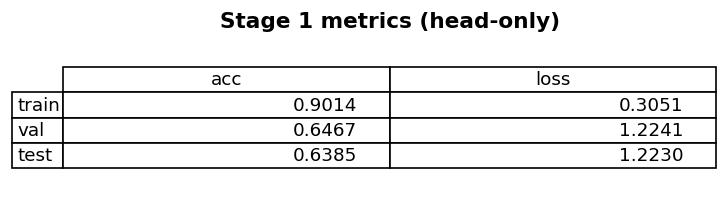

In [83]:
def plot_metrics_table(metrics, title):
    rows = ['train', 'val', 'test']
    cols = ['acc', 'loss']
    data = [[metrics[r][c] for c in cols] for r in rows]

    fig, ax = plt.subplots(figsize=(6.2, 1.8))
    ax.axis('off')

    table = ax.table(
        cellText=[[f"{v:.4f}" for v in row] for row in data],
        rowLabels=rows,
        colLabels=cols,
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.5)

    ax.set_title(title, pad=12)
    plt.tight_layout()
    plt.show()

plot_metrics_table(metrics_stage1, title='Stage 1 metrics (head-only)')


✍️ **Stage 1 takeaway (paste final numbers)**

- train acc/loss: **[...]**
- val acc/loss: **[...]**
- test acc/loss: **[...]**
- Gap train→val: **[...] pp**; train→test: **[...] pp**
- Interpretation: **[underfit / good fit / overfit]** because **[...]**


### Stage 1 diagnostics (for slides)

A set of visuals that explain model quality beyond a single accuracy number.


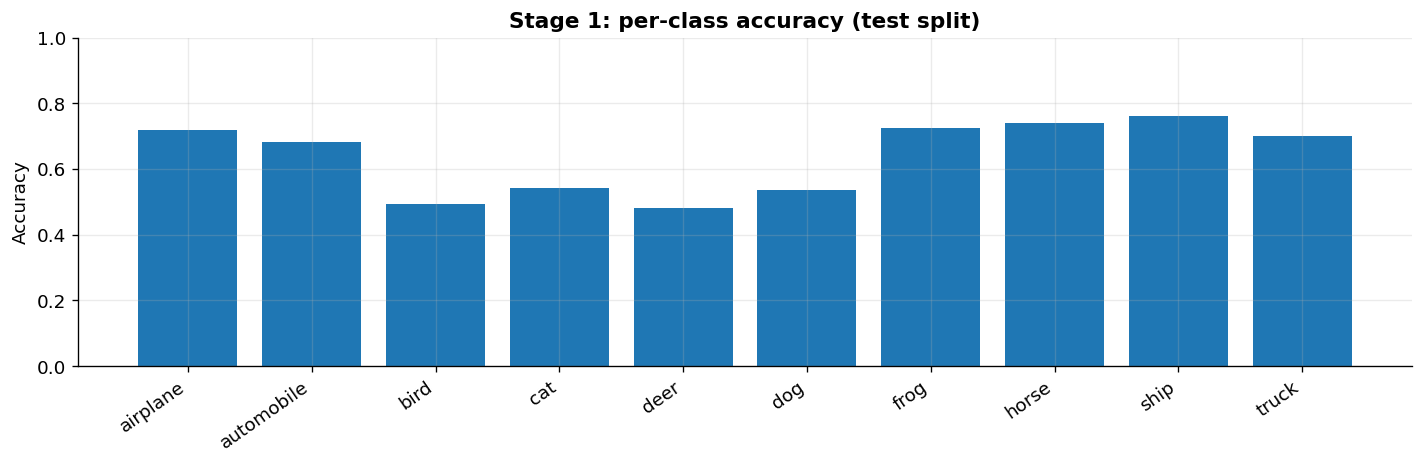

<Figure size 960x960 with 0 Axes>

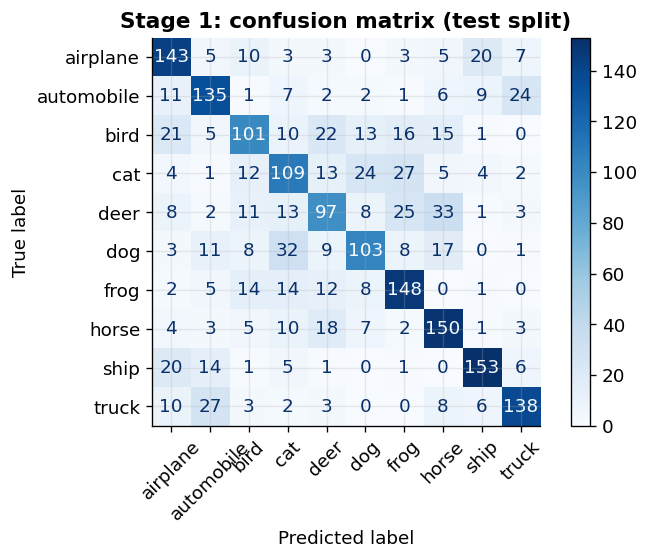

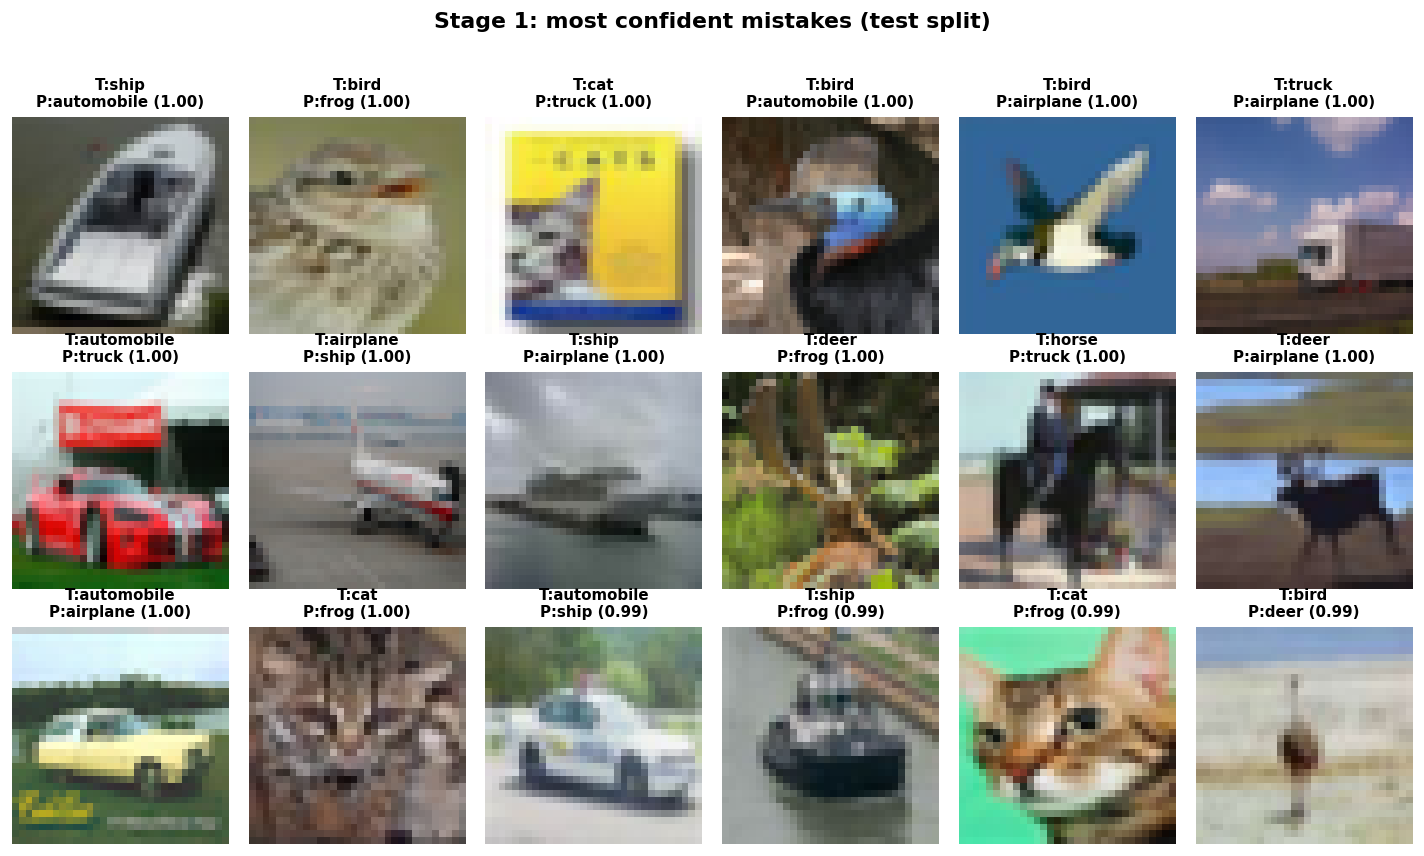

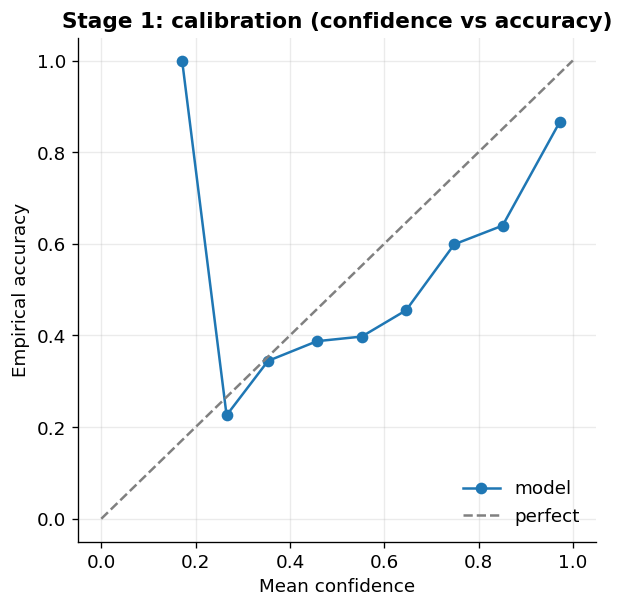

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve

# Cache stage-1 predictions (before fine-tuning)
y_prob_stage1 = model.predict(X_test_pp, verbose=0)
y_pred_stage1 = np.argmax(y_prob_stage1, axis=1)
y_true_test = y_test.reshape(-1)

# (1) Per-class accuracy (Stage 1)
per_class_acc_s1 = []
for cls in range(len(class_names)):
    mask = (y_true_test == cls)
    per_class_acc_s1.append(float((y_pred_stage1[mask] == cls).mean()))

plt.figure(figsize=(12, 4))
plt.bar(class_names, per_class_acc_s1)
plt.xticks(rotation=35, ha='right')
plt.ylim(0, 1)
plt.title('Stage 1: per-class accuracy (test split)')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

# (2) Confusion matrix (Stage 1)
cm1 = confusion_matrix(y_true_test, y_pred_stage1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=class_names)
plt.figure(figsize=(8, 8))
disp1.plot(cmap='Blues', xticks_rotation=45, values_format='d')
plt.title('Stage 1: confusion matrix (test split)')
plt.tight_layout()
plt.show()

# (3) Top confident mistakes gallery (Stage 1)
conf = y_prob_stage1.max(axis=1)
wrong = (y_pred_stage1 != y_true_test)
wrong_idx = np.where(wrong)[0]
# take most confident wrong predictions
k = 18
sel = wrong_idx[np.argsort(conf[wrong_idx])[::-1][:k]] if len(wrong_idx) else np.array([], dtype=int)

if len(sel):
    plt.figure(figsize=(12, 7))
    for i, idx in enumerate(sel, start=1):
        plt.subplot(3, 6, i)
        plt.imshow(X_test_raw[idx])
        t = class_names[int(y_true_test[idx])]
        p = class_names[int(y_pred_stage1[idx])]
        plt.title(f'T:{t}\nP:{p} ({conf[idx]:.2f})', fontsize=9)
        plt.axis('off')
    plt.suptitle('Stage 1: most confident mistakes (test split)', y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No mistakes found (unexpected)')

# (4) Calibration curve (Stage 1) — using max probability as confidence
# Treat "correct" as 1/0 and plot reliability of confidence
correct = (y_pred_stage1 == y_true_test).astype(int)
prob_true, prob_pred = calibration_curve(correct, conf, n_bins=10, strategy='uniform')
plt.figure(figsize=(5.2, 5.2))
plt.plot(prob_pred, prob_true, marker='o', label='model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='perfect')
plt.title('Stage 1: calibration (confidence vs accuracy)')
plt.xlabel('Mean confidence')
plt.ylabel('Empirical accuracy')
plt.legend()
plt.tight_layout()
plt.show()


✍️ **Stage 1 error analysis (1–3 bullets)**

- Most confused classes: **[...]** (from confusion matrix)
- Typical failure cases: **[...]** (from mistakes gallery)
- Calibration: model is **[overconfident / well-calibrated]** in high-confidence region.


## 8. Stage 2 training: fine-tuning (unfreeze base)

**Goal**
Adapt the pretrained backbone to CIFAR-10.

**Key rule**
Use a smaller learning rate during fine-tuning.


In [85]:
history_ft = None

if MODEL_TYPE == 'resnet50_tl':
    # Unfreeze only the last part of the backbone (faster on CPU than full fine-tuning)
    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    lr = 1e-5
else:
    # For scratch ResNet: Stage 2 = continue training with lower LR
    lr = 3e-4

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

if USE_AUGMENTATION:
    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=callbacks,
        verbose=1
    )
else:
    history_ft = model.fit(
        X_train_pp, y_train,
        validation_data=(X_val_pp, y_val),
        epochs=10,
        batch_size=64,
        callbacks=callbacks,
        verbose=1
    )


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 209ms/step - accuracy: 0.8104 - loss: 0.5386 - val_accuracy: 0.6447 - val_loss: 1.2046
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 0.8259 - loss: 0.4780 - val_accuracy: 0.6427 - val_loss: 1.2430
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 53s 213ms/step - accuracy: 0.8597 - loss: 0.4095 - val_accuracy: 0.6397 - val_loss: 1.2419
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 225ms/step - accuracy: 0.8717 - loss: 0.3712 - val_accuracy: 0.6377 - val_loss: 1.2433


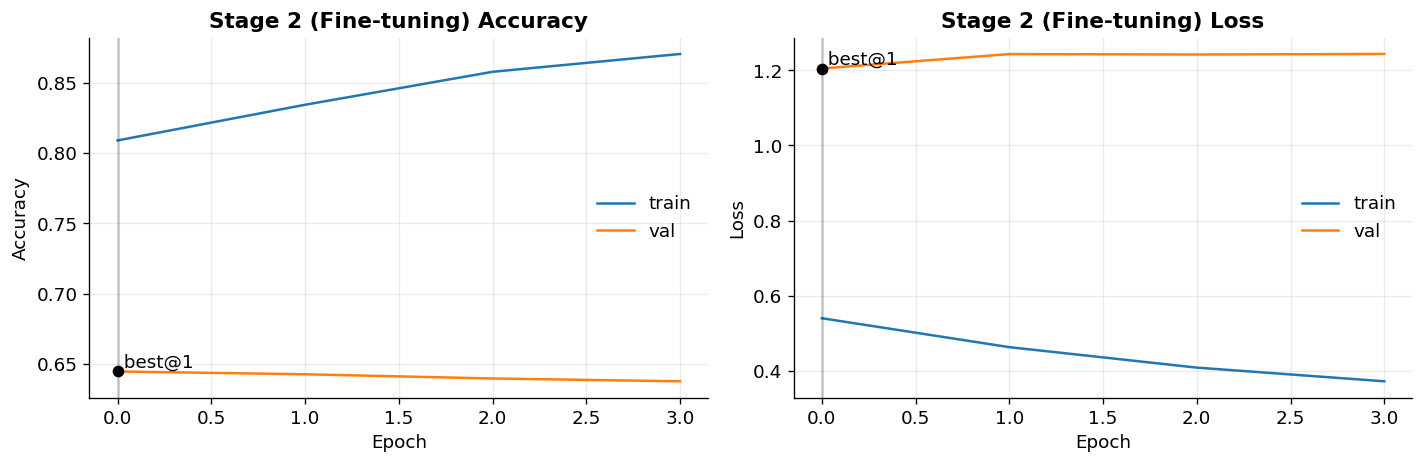

In [86]:
plot_history(history_ft, title_prefix='Stage 2 (Fine-tuning)')


## 10. Final evaluation summary (train/val/test)

Below are the final metrics after fine-tuning and a short interpretation + next improvement ideas.


In [87]:
from IPython.display import display, Markdown

def eval_to_dict(X_pp, y_true):
    loss, acc = model.evaluate(X_pp, y_true, verbose=0)
    return {'loss': float(loss), 'acc': float(acc)}

def format_pct(x):
    return f"{x*100:.2f}%"

def render_final_summary(metrics, title='Final'):
    tr, va, te = metrics['train'], metrics['val'], metrics['test']
    gap_val = tr['acc'] - va['acc']
    gap_test = tr['acc'] - te['acc']

    lines = []
    lines.append(f"### {title}")
    lines.append("")
    lines.append("**Metrics**")
    lines.append(f"- train: acc={tr['acc']:.4f}, loss={tr['loss']:.4f}")
    lines.append(f"-   val: acc={va['acc']:.4f}, loss={va['loss']:.4f}")
    lines.append(f"-  test: acc={te['acc']:.4f}, loss={te['loss']:.4f}")
    lines.append("")
    lines.append("**Gaps**")
    lines.append(f"- train−val acc gap: {format_pct(gap_val)}")
    lines.append(f"- train−test acc gap: {format_pct(gap_test)}")
    lines.append("")

    lines.append("**Why metrics may be low**")
    lines.append("- CIFAR-10 images are tiny (32×32): a ResNet50 pretrained on ImageNet may need strong augmentations to adapt well.")
    lines.append("- We train on 10k instead of the full 50k training set, which significantly lowers the achievable ceiling.")
    lines.append("- Validation is only 3% (~300 images): the estimate can be noisy, especially per class.")

    lines.append("")
    lines.append("**What to improve next (priority)**")
    lines.append("1) Data augmentation (RandomFlip/RandomCrop/ColorJitter-like) + more epochs with an LR schedule.")
    lines.append("2) Fine-tuning: carefully unfreeze more layers and tune the learning rate.")
    lines.append("3) Try a different backbone: `MobileNetV2`/`EfficientNetB0` are often strong on CIFAR in speed/quality.")
    lines.append("4) If allowed: train on the full 50k (or at least 20–30k) for a fairer comparison.")

    display(Markdown("\n".join(lines)))

metrics_final = {
    'train': eval_to_dict(X_train_pp, y_train),
    'val': eval_to_dict(X_val_pp, y_val),
    'test': eval_to_dict(X_test_pp, y_test),
}

render_final_summary(metrics_final, title='After fine-tuning')


### After fine-tuning

**Metrics**
- train: acc=0.9055, loss=0.3098
-   val: acc=0.6447, loss=1.2046
-  test: acc=0.6340, loss=1.1796

**Gaps**
- train−val acc gap: 26.08%
- train−test acc gap: 27.15%

**Why metrics may be low**
- CIFAR-10 images are tiny (32×32): a ResNet50 pretrained on ImageNet may need strong augmentations to adapt well.
- We train on 10k instead of the full 50k training set, which significantly lowers the achievable ceiling.
- Validation is only 3% (~300 images): the estimate can be noisy, especially per class.

**What to improve next (priority)**
1) Data augmentation (RandomFlip/RandomCrop/ColorJitter-like) + more epochs with an LR schedule.
2) Fine-tuning: carefully unfreeze more layers and tune the learning rate.
3) Try a different backbone: `MobileNetV2`/`EfficientNetB0` are often strong on CIFAR in speed/quality.
4) If allowed: train on the full 50k (or at least 20–30k) for a fairer comparison.

### Metrics table (final)

Train/val/test comparison after fine-tuning.


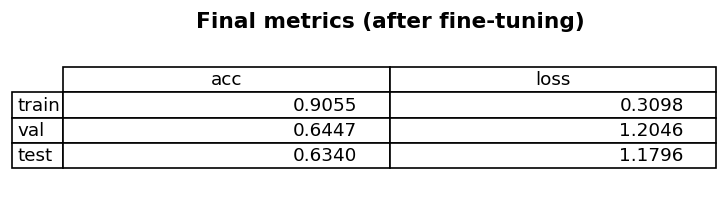

In [88]:
plot_metrics_table(metrics_final, title='Final metrics (after fine-tuning)')


✍️ **Final takeaway (paste final numbers)**

- Final train/val/test acc/loss: **[...]**
- Improvement vs Stage 1 (test acc): **Δ = [...]**
- Gap change: **[smaller / larger]** → generalization **[improved / worsened]**
- Conclusion in 1 sentence: **[...]**


## Slide pack: final comparisons and standout figures

These figures work well for storytelling: what improved after fine-tuning, where the model still fails, and how it compares to the CatBoost baseline.


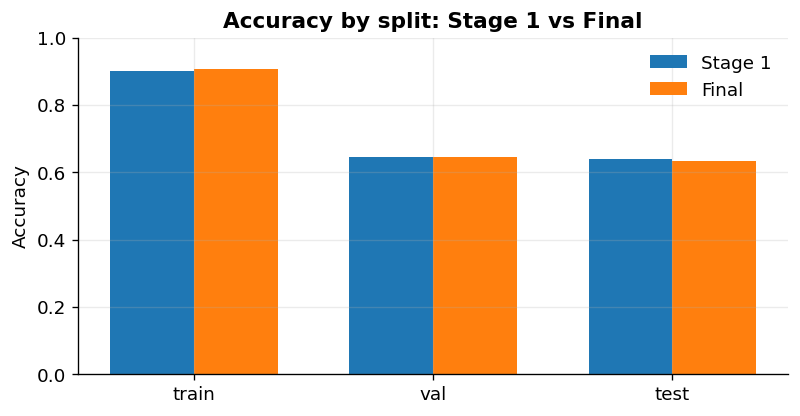

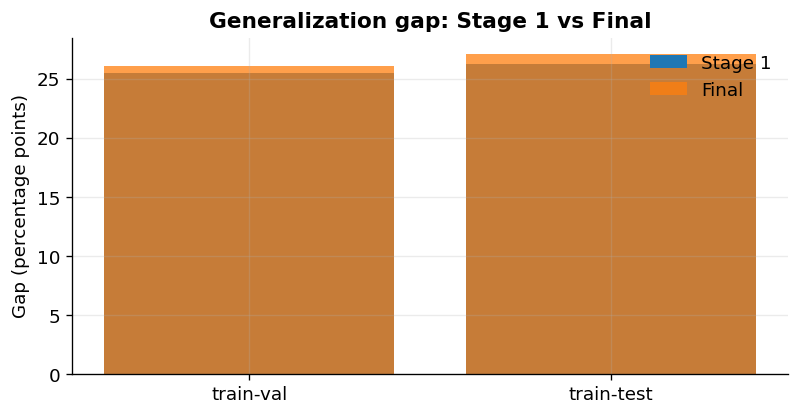

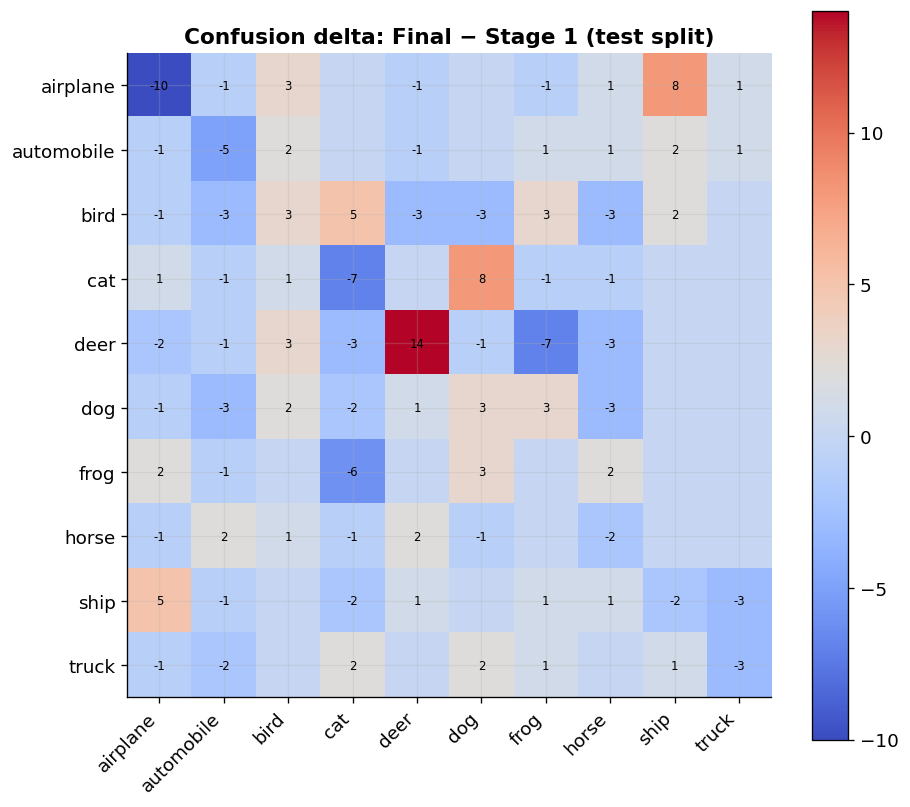

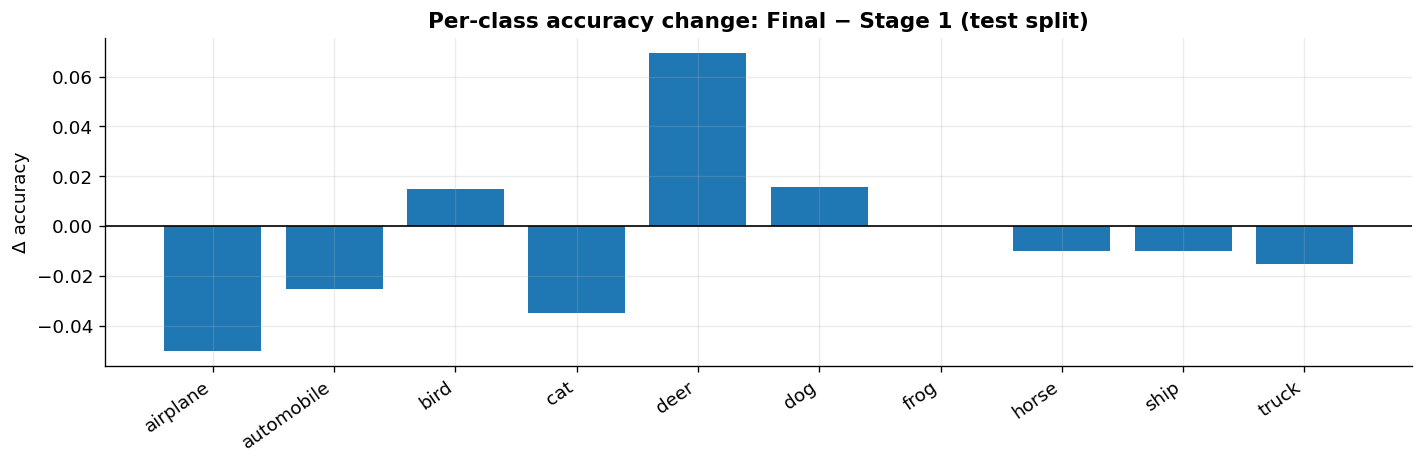

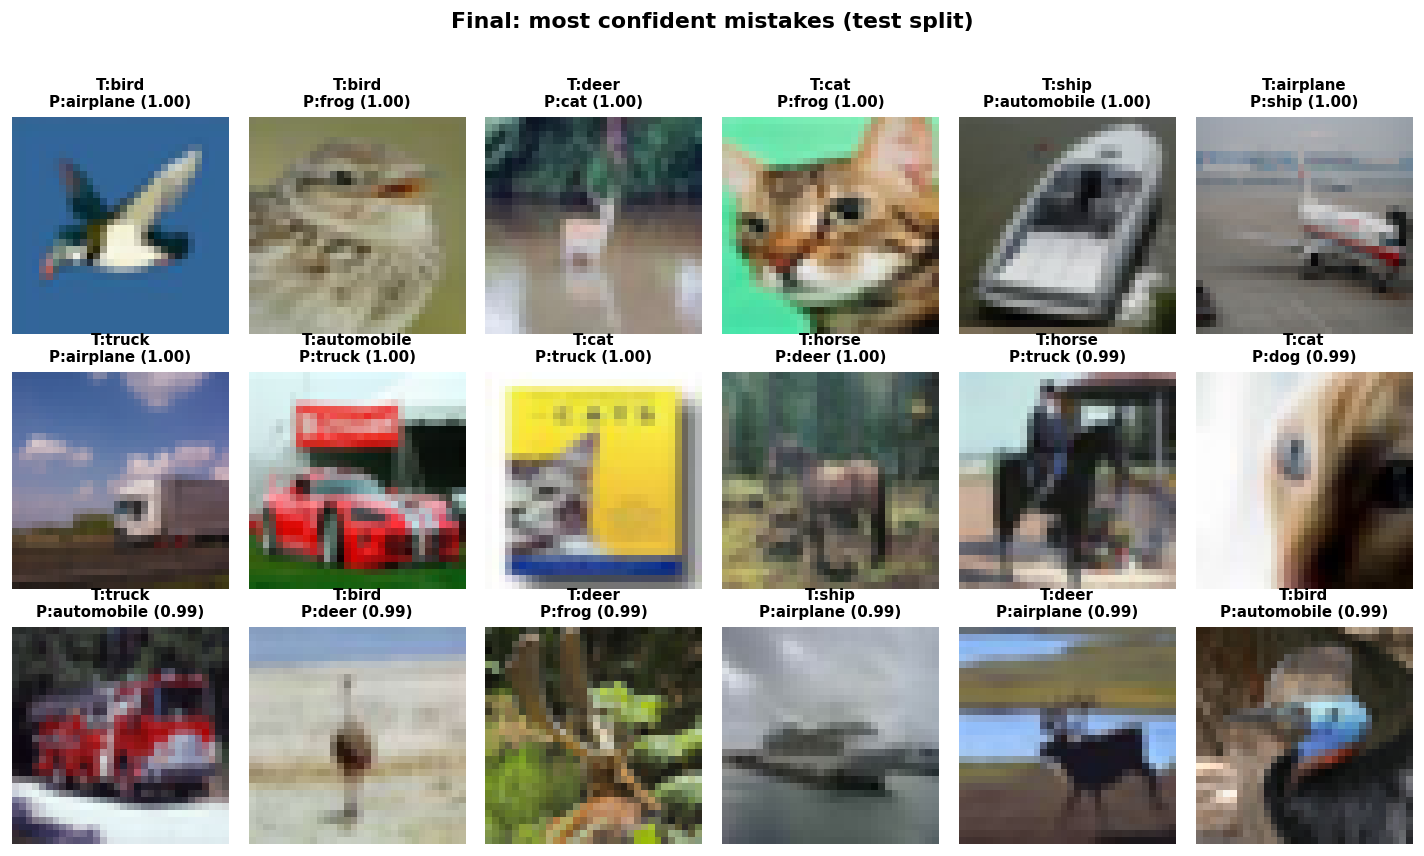

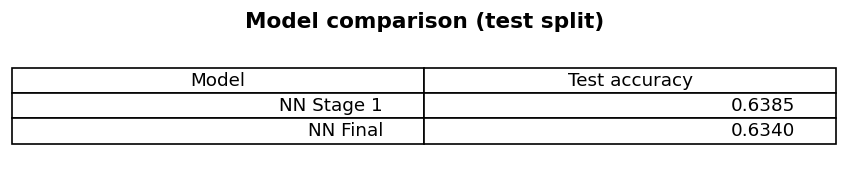

In [ ]:
from sklearn.metrics import confusion_matrix

# Cache final predictions
_y_prob_final = model.predict(X_test_pp, verbose=0)
_y_pred_final = np.argmax(_y_prob_final, axis=1)
_y_true = y_test.reshape(-1)

# (5) Gap chart: train/val/test acc comparison (Stage1 vs Final)
# Requires metrics_stage1 and metrics_final
labels = ['train', 'val', 'test']
stage1_acc = [metrics_stage1[k]['acc'] for k in labels]
final_acc = [metrics_final[k]['acc'] for k in labels]

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(6.8, 3.6))
plt.bar(x - width/2, stage1_acc, width, label='Stage 1')
plt.bar(x + width/2, final_acc, width, label='Final')
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Accuracy by split: Stage 1 vs Final')
plt.legend()
plt.tight_layout()
plt.show()

# (6) Generalization gaps as % (train-val, train-test)
import numpy as np

def gaps(metrics):
    return {
        'train-val': float(metrics['train']['acc'] - metrics['val']['acc']),
        'train-test': float(metrics['train']['acc'] - metrics['test']['acc'])
    }

g1 = gaps(metrics_stage1)
g2 = gaps(metrics_final)

plt.figure(figsize=(6.8, 3.6))
plt.bar(['train-val','train-test'], [g1['train-val']*100, g1['train-test']*100], label='Stage 1')
plt.bar(['train-val','train-test'], [g2['train-val']*100, g2['train-test']*100], alpha=0.75, label='Final')
plt.ylabel('Gap (percentage points)')
plt.title('Generalization gap: Stage 1 vs Final')
plt.legend()
plt.tight_layout()
plt.show()

# (7) Confusion matrix delta (Final - Stage 1)
cm_final = confusion_matrix(_y_true, _y_pred_final)
# cm1 is from Stage 1 diagnostics cell
cm_delta = cm_final - cm1

plt.figure(figsize=(8, 7))
plt.imshow(cm_delta, cmap='coolwarm')
plt.title('Confusion delta: Final − Stage 1 (test split)')
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(range(len(class_names)), class_names)
# annotate values
for (i, j), v in np.ndenumerate(cm_delta):
    if v != 0:
        plt.text(j, i, str(int(v)), ha='center', va='center', fontsize=7, color='black')
plt.tight_layout()
plt.show()

# (8) Per-class accuracy delta
per_class_acc_final = []
for cls in range(len(class_names)):
    mask = (_y_true == cls)
    per_class_acc_final.append(float((_y_pred_final[mask] == cls).mean()))

delta = np.array(per_class_acc_final) - np.array(per_class_acc_s1)
plt.figure(figsize=(12, 4))
plt.bar(class_names, delta)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=35, ha='right')
plt.title('Per-class accuracy change: Final − Stage 1 (test split)')
plt.ylabel('Δ accuracy')
plt.tight_layout()
plt.show()

# (9) Top confident mistakes gallery (Final)
conf_final = _y_prob_final.max(axis=1)
wrong_final = (_y_pred_final != _y_true)
wrong_idx = np.where(wrong_final)[0]

k = 18
sel = wrong_idx[np.argsort(conf_final[wrong_idx])[::-1][:k]] if len(wrong_idx) else np.array([], dtype=int)

if len(sel):
    plt.figure(figsize=(12, 7))
    for i, idx in enumerate(sel, start=1):
        plt.subplot(3, 6, i)
        plt.imshow(X_test_raw[idx])
        t = class_names[int(_y_true[idx])]
        p = class_names[int(_y_pred_final[idx])]
        plt.title(f'T:{t}\nP:{p} ({conf_final[idx]:.2f})', fontsize=9)
        plt.axis('off')
    plt.suptitle('Final: most confident mistakes (test split)', y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.show()

# (10) Model comparison table (Neural vs CatBoost)
# If cb_metrics exists (CatBoost cell ran), include it.
rows = []

rows.append(('NN Stage 1', metrics_stage1['test']['acc']))
rows.append(('NN Final', metrics_final['test']['acc']))
if 'cb_metrics' in globals():
    rows.append(('CatBoost', cb_metrics['test']['acc']))

fig, ax = plt.subplots(figsize=(7.2, 1.6))
ax.axis('off')

table = ax.table(
    cellText=[[name, f"{acc:.4f}"] for name, acc in rows],
    colLabels=['Model', 'Test accuracy'],
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)
ax.set_title('Model comparison (test split)', pad=12)
plt.tight_layout()
plt.show()


## Baselines on deep features (optional)

Run these after Stage 1/2. Enable by setting `RUN_BASELINES=True` in the experiment configuration.


### Baseline: Logistic Regression on ResNet50 features

A fast classical baseline: extract deep features with the frozen ResNet50 backbone, then train a linear classifier.


/Users/egortatsiy/Projects/CV project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/egortatsiy/Projects/CV project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/egortatsiy/Projects/CV project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/egortatsiy/Projects/CV project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + 

LogReg accuracy: {'train': {'acc': 0.9999374960935058}, 'val': {'acc': 0.5482258870564718}, 'test': {'acc': 0.55}}


/Users/egortatsiy/Projects/CV project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/egortatsiy/Projects/CV project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/egortatsiy/Projects/CV project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/egortatsiy/Projects/CV project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/egortatsiy/Projects/CV project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/egortatsiy/Projects/CV project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


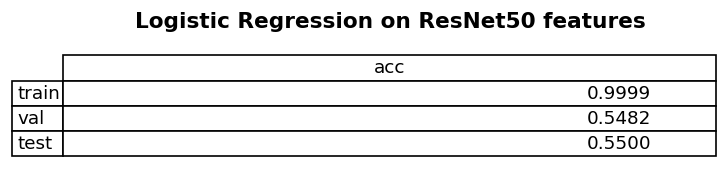

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

if (not RUN_BASELINES) or (MODEL_TYPE != 'resnet50_tl'):
    print('Skipping Logistic Regression baseline (requires MODEL_TYPE=resnet50_tl and RUN_BASELINES=True).')
else:
    # Feature extractor: ResNet50 backbone -> GlobalAveragePooling
    feat_inputs = base_model.input
    feat_outputs = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    feature_extractor = tf.keras.Model(feat_inputs, feat_outputs)

    def extract_features(X_pp, batch_size=256):
        return feature_extractor.predict(X_pp, batch_size=batch_size, verbose=0)

    Xtr_feat = extract_features(X_train_pp)
    Xva_feat = extract_features(X_val_pp)
    Xte_feat = extract_features(X_test_pp)

    ytr = y_train.reshape(-1)
    yva = y_val.reshape(-1)
    yte = y_test.reshape(-1)

    # Standardize features + multinomial logistic regression
    logreg = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=2000,
            n_jobs=-1,
            multi_class='multinomial',
            solver='lbfgs'
        ))
    ])

    logreg.fit(Xtr_feat, ytr)

    def acc(Xf, y):
        return float(logreg.score(Xf, y))

    logreg_metrics = {
        'train': {'acc': acc(Xtr_feat, ytr)},
        'val': {'acc': acc(Xva_feat, yva)},
        'test': {'acc': acc(Xte_feat, yte)},
    }

    print('LogReg accuracy:', logreg_metrics)

    # Slide-friendly table
    fig, ax = plt.subplots(figsize=(6.2, 1.6))
    ax.axis('off')
    rows = ['train', 'val', 'test']
    data = [[logreg_metrics[r]['acc']] for r in rows]
    table = ax.table(
        cellText=[[f"{v[0]:.4f}"] for v in data],
        rowLabels=rows,
        colLabels=['acc'],
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.6)
    ax.set_title('Logistic Regression on ResNet50 features', pad=12)
    plt.tight_layout()
    plt.show()


## 6.5. Baseline: CatBoost on frozen ResNet50 features (optional)

Idea: use a frozen ResNet50 as a **feature extractor** and train a `CatBoostClassifier` on those features.

Why this is great for a presentation:
- a strong baseline from a different model family,
- easy to compare quality/speed against the neural-network head.

Note: if `catboost` is not installed, the cell below prints how to install it.


0:	learn: 0.3602725	test: 0.3328336	best: 0.3328336 (0)	total: 2.64s	remaining: 1h 27m 53s
200:	learn: 0.7228577	test: 0.6066967	best: 0.6081959 (195)	total: 9m 19s	remaining: 1h 23m 27s
400:	learn: 0.8048003	test: 0.6211894	best: 0.6241879 (348)	total: 18m 46s	remaining: 1h 14m 51s
600:	learn: 0.8508032	test: 0.6331834	best: 0.6351824 (584)	total: 30m 14s	remaining: 1h 10m 23s
800:	learn: 0.8836802	test: 0.6361819	best: 0.6401799 (724)	total: 40m 49s	remaining: 1h 1m 7s
Stopped by overfitting detector  (80 iterations wait)

bestTest = 0.64017991
bestIteration = 724

Shrink model to first 725 iterations.
CatBoost accuracy: {'train': {'acc': 0.8735545971623226}, 'val': {'acc': 0.6401799100449775}, 'test': {'acc': 0.637}}


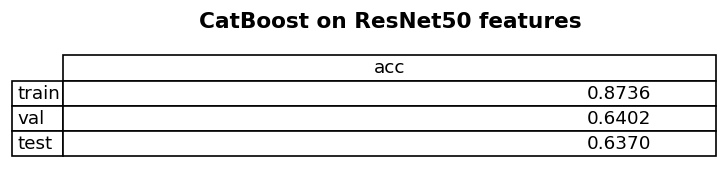

In [91]:
if (not RUN_BASELINES) or (not RUN_CATBOOST) or (MODEL_TYPE != 'resnet50_tl'):
    print('Skipping CatBoost baseline (requires MODEL_TYPE=resnet50_tl, RUN_BASELINES=True, RUN_CATBOOST=True).')
else:
    try:
        from catboost import CatBoostClassifier
    except ImportError as e:
        print('CatBoost is not installed. Install it with: pip install catboost')
        CatBoostClassifier = None

    if CatBoostClassifier is not None:
        # Build a feature extractor: ResNet50 -> GlobalAveragePooling
        feat_inputs = base_model.input
        feat_outputs = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
        feature_extractor = tf.keras.Model(feat_inputs, feat_outputs)

        def extract_features(X_pp, batch_size=256):
            return feature_extractor.predict(X_pp, batch_size=batch_size, verbose=0)

        Xtr_feat = extract_features(X_train_pp)
        Xva_feat = extract_features(X_val_pp)
        Xte_feat = extract_features(X_test_pp)

        ytr = y_train.reshape(-1)
        yva = y_val.reshape(-1)
        yte = y_test.reshape(-1)

        cb = CatBoostClassifier(
            loss_function='MultiClass',
            eval_metric='Accuracy',
            iterations=2000,
            learning_rate=0.05,
            depth=8,
            random_seed=42,
            od_type='Iter',
            od_wait=80,
            verbose=200
        )

        cb.fit(Xtr_feat, ytr, eval_set=(Xva_feat, yva), use_best_model=True)

        def cb_acc(X_feat, y_true):
            pred = cb.predict(X_feat).reshape(-1).astype(int)
            return float((pred == y_true).mean())

        cb_metrics = {
            'train': {'acc': cb_acc(Xtr_feat, ytr)},
            'val':   {'acc': cb_acc(Xva_feat, yva)},
            'test':  {'acc': cb_acc(Xte_feat, yte)},
        }

        print('CatBoost accuracy:', cb_metrics)

        # Slide-friendly table
        fig, ax = plt.subplots(figsize=(6.2, 1.6))
        ax.axis('off')
        rows = ['train', 'val', 'test']
        cols = ['acc']
        data = [[cb_metrics[r][c] for c in cols] for r in rows]
        table = ax.table(
            cellText=[[f"{v:.4f}" for v in row] for row in data],
            rowLabels=rows,
            colLabels=cols,
            loc='center'
        )
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 1.6)
        ax.set_title('CatBoost on ResNet50 features', pad=12)
        plt.tight_layout()
        plt.show()


## Save experiment results

This step appends the current run to `artifacts/experiments.jsonl` and updates `artifacts/experiments.csv`.

After this cell runs, open `Experiments.ipynb` to see a comparison table and plots.


In [92]:
from scripts.experiment_log import append_and_export

JSONL_PATH = 'artifacts/experiments.jsonl'
CSV_PATH = 'artifacts/experiments.csv'

# Best val accuracy from histories (if available)
stage1_best_val_acc = float(max(history_head.history.get('val_accuracy', [float('nan')]))) if 'history_head' in globals() else float('nan')
stage2_best_val_acc = float(max(history_ft.history.get('val_accuracy', [float('nan')]))) if 'history_ft' in globals() else float('nan')

row = {
    'exp_id': EXP_ID,
    'exp_name': EXP_NAME,
    'dataset': DATASET_NAME,
    'n_samples': int(N_SAMPLES),
    'split_train': float(SPLIT_TRAIN),
    'split_val': float(SPLIT_VAL),
    'split_test': float(SPLIT_TEST),
    'random_state': int(RANDOM_STATE),
    'model_family': 'Transfer learning + deep-feature baselines',
    'model_name': ('ResNet50 backbone + custom head' if MODEL_TYPE == 'resnet50_tl' else 'CIFAR ResNet20 (scratch)'),
    'stage1_train_acc': float(metrics_stage1['train']['acc']),
    'stage1_val_acc': float(metrics_stage1['val']['acc']),
    'stage1_test_acc': float(metrics_stage1['test']['acc']),
    'stage1_train_loss': float(metrics_stage1['train']['loss']),
    'stage1_val_loss': float(metrics_stage1['val']['loss']),
    'stage1_test_loss': float(metrics_stage1['test']['loss']),
    'stage1_best_val_acc': stage1_best_val_acc,
    'stage2_train_acc': float(metrics_final['train']['acc']),
    'stage2_val_acc': float(metrics_final['val']['acc']),
    'stage2_test_acc': float(metrics_final['test']['acc']),
    'stage2_train_loss': float(metrics_final['train']['loss']),
    'stage2_val_loss': float(metrics_final['val']['loss']),
    'stage2_test_loss': float(metrics_final['test']['loss']),
    'stage2_best_val_acc': stage2_best_val_acc,
    # Baselines (optional)
    'baseline_logreg_test_acc': float(logreg_metrics['test']['acc']) if 'logreg_metrics' in globals() else float('nan'),
    'baseline_catboost_test_acc': float(cb_metrics['test']['acc']) if 'cb_metrics' in globals() else float('nan'),
    'stage1_gap_train_val_pp': float((metrics_stage1['train']['acc'] - metrics_stage1['val']['acc']) * 100.0),
    'stage1_gap_train_test_pp': float((metrics_stage1['train']['acc'] - metrics_stage1['test']['acc']) * 100.0),
    'stage2_gap_train_val_pp': float((metrics_final['train']['acc'] - metrics_final['val']['acc']) * 100.0),
    'stage2_gap_train_test_pp': float((metrics_final['train']['acc'] - metrics_final['test']['acc']) * 100.0),
    'notes': '',
}

append_and_export(JSONL_PATH, CSV_PATH, row)
print('Saved to:', JSONL_PATH)
print('Exported:', CSV_PATH)


Saved to: artifacts/experiments.jsonl
Exported: artifacts/experiments.csv


✍️ **Model comparison (story point)**

- Best model on test: **[...]**
- Why: **[...]** (e.g., representation learning vs tabular booster on features)
- Trade-offs: speed / complexity / interpretability: **[...]**


### Observation notes (fill in after training)

- Stage 1: (e.g., fast gains early, then plateau)
- Stage 2: (e.g., slower but continued improvement / instability)
- Overfitting signs: (if any)
- Runtime notes: (CPU/GPU, total time)


## 9. Evaluation on the test set

We evaluate on the untouched test set to estimate generalization.


In [93]:
# Metrics on the held-out test split
test_loss, test_acc = model.evaluate(X_test_pp, y_test, verbose=0)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)


Test loss: 1.1795917749404907
Test accuracy: 0.6340000033378601


### Optional: confusion matrix (error analysis)

A confusion matrix can reveal which classes are commonly confused (e.g., cat vs dog, truck vs automobile).
This is helpful for interpretation in the final presentation.


<Figure size 960x960 with 0 Axes>

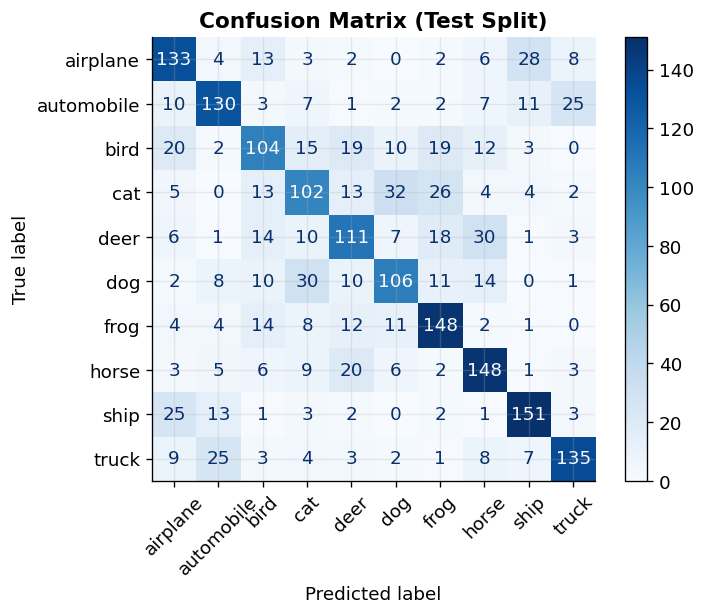

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = y_test.flatten()
y_prob = model.predict(X_test_pp, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8, 8))
disp.plot(cmap='Blues', xticks_rotation=45, values_format='d')
plt.title('Confusion Matrix (Test Split)')
plt.show()


## 11. Save artifacts (optional)

Saving artifacts helps reproducibility and makes it easier to reuse results for the presentation.
In Colab, you can also save to Google Drive.


In [95]:
# Example: save model (uncomment if needed)
# model.save('cifar10_resnet50_transfer_learning.keras')

# Example: save histories for later plotting
# import json
# with open('history_head.json', 'w') as f:
#     json.dump(history_head.history, f)
# with open('history_ft.json', 'w') as f:
#     json.dump(history_ft.history, f)


## Slide checklist (copy-paste into presentation)

1) Problem & dataset (CIFAR-10, 10k subset)
2) Pipeline diagram (load → split → preprocess → model → metrics)
3) Stratified split plot (class distribution)
4) Stage 1 curves + Stage 1 metrics table + 1-sentence takeaway
5) Error analysis (confusion matrix + top mistakes)
6) Stage 2 curves + Final metrics table
7) Improvements vs Stage 1 (gap chart / deltas)
8) Model comparison table (NN vs CatBoost baseline)

✍️ After you run the notebook, fill the marked blocks above and take clean screenshots of the plots/tables.


## 10. Conclusions and next improvements

Write 5–10 bullet points answering:
- What worked well?
- What was hard or slow?
- Did we see overfitting?
- What would we do next with more time/compute?

This section will be reused for the final Google Slides presentation.


## Appendix: saved run summary (optional)

This section reads `artifacts/run_summary.json` if you saved it during a run. You can ignore it for the main story.


In [96]:
import json

with open('artifacts/run_summary.json', 'r') as f:
    s = json.load(f)

print('TensorFlow:', s.get('tensorflow'))
print('GPUs:', s.get('gpus'))

print('Stage 1 (head-only):')
print('  epochs_ran   :', s['stage1']['epochs_ran'])
print('  best val_acc :', s['stage1']['val_acc_best'])
print('  best val_loss:', s['stage1']['val_loss_best'])

print('Stage 2 (fine-tune last 20):')
print('  epochs_ran   :', s['stage2']['epochs_ran'])
print('  best val_acc :', s['stage2']['val_acc_best'])
print('  best val_loss:', s['stage2']['val_loss_best'])


TensorFlow: 2.20.0
GPUs: []
Stage 1 (head-only):
  epochs_ran   : 9
  best val_acc : 0.6359999775886536
  best val_loss: 1.1533136367797852
Stage 2 (fine-tune last 20):
  epochs_ran   : 2
  best val_acc : 0.6455000042915344
  best val_loss: 1.1883913278579712
